In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns


In [2]:
mc_df = pd.read_csv('../csv_files/menu.csv')
mc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Category                       260 non-null    object 
 1   Item                           260 non-null    object 
 2   Serving Size                   260 non-null    object 
 3   Calories                       260 non-null    int64  
 4   Calories from Fat              260 non-null    int64  
 5   Total Fat                      260 non-null    float64
 6   Total Fat (% Daily Value)      260 non-null    int64  
 7   Saturated Fat                  260 non-null    float64
 8   Saturated Fat (% Daily Value)  260 non-null    int64  
 9   Trans Fat                      260 non-null    float64
 10  Cholesterol                    260 non-null    int64  
 11  Cholesterol (% Daily Value)    260 non-null    int64  
 12  Sodium                         260 non-null    int

In [3]:
#1.a
X=mc_df[['Carbohydrates', 'Protein', 'Total Fat']].values
y=mc_df[['Calories']].values

model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [4]:
print('y Intercept: ', '%.2f' % model.intercept_)
print('Carbohydrate Coefficent: ', '%.2f' % model.coef_[0][0])
print('Protein Coefficent:', '%.2f' % model.coef_[0][1])
print('Total Fat Coefficent: ', '%.2f' % model.coef_[0][2])

y Intercept:  -1.83
Carbohydrate Coefficent:  3.98
Protein Coefficent: 4.05
Total Fat Coefficent:  9.02


/var/folders/xk/fhgbj8qj60n54b05mpfnck0w0000gn/T/ipykernel_11878/1135445955.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('y Intercept: ', '%.2f' % model.intercept_)


In [5]:
#1.b

X=mc_df[['Total Fat']].values
y=mc_df[['Calories']].values

model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [6]:
print('y Intercept: ', '%.2f' % model.intercept_)
print('Total Fat Coefficent: ', '%.2f' % model.coef_[0][0])

y Intercept:  151.59
Total Fat Coefficent:  15.30


/var/folders/xk/fhgbj8qj60n54b05mpfnck0w0000gn/T/ipykernel_11878/247925070.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('y Intercept: ', '%.2f' % model.intercept_)


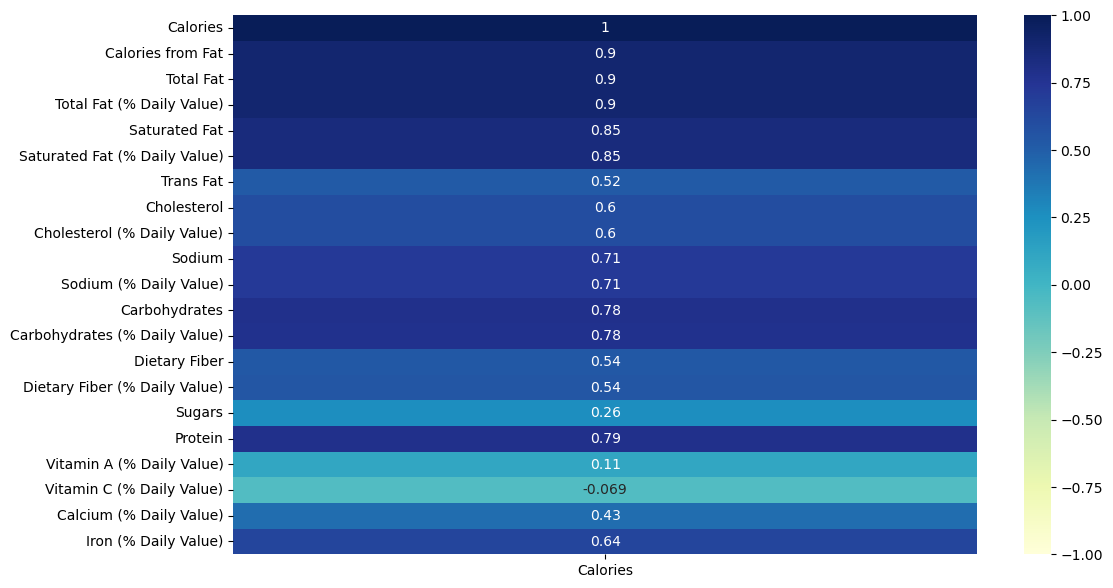

In [7]:
mc_numericals = mc_df.select_dtypes(exclude=['object'])
corr_matrix = mc_numericals.corr()

plt.figure(figsize=(12, 7))

corr_cal = corr_matrix[['Calories']]
sns.heatmap(corr_cal, annot=True, cmap="YlGnBu", vmin=-1, vmax=1)

plt.show()

In [8]:
#1.c

#Finding MSE on training set

X= mc_numericals.drop(columns=['Calories'])
y=mc_numericals[['Calories']].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1)

model.fit(X_train,y_train)

y_train_predict = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_train_predict)


y_test_predict = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_predict)

print('MSE of train set: %.2f' % mse_train)
print('MSE of test set: %.2f' % mse_test)

MSE of train set: 20.60
MSE of test set: 26.79
